In [1]:
from resources.imports import *

from resources.lattices import geometry, pStrainProperties, effProperties
from resources.MLdata import DATA, load_data, prep_UTdata, prep_FTdata, remove_outliers, split_data, save_MLdata, \
                             plot_sampling, locSims, get_stats, plot_frequency, plot_properties, plot_curve

In [2]:
### Global Inputs

mode = ("compare", "Target-xs")

DAT = DATA(path=1, 
           path_add="",
           LAT="tri", 
           dis="disNodes", 
           dN=0.2)

if mode is not None:
    if mode[0].lower() == "compare":
        DAT = DATA(path=1, 
           path_add="",
           LAT=DAT.LAT, 
           dis=DAT.dis, 
           dN=DAT.dN)
        
        DATc = DATA(path=1, 
           path_add=mode[1],
           LAT=DAT.LAT, 
           dis=DAT.dis, 
           dN=DAT.dN)

l = 0.010
if DAT.LAT.lower() == "fcc":
    nnx = 16
    MODEL = "ductile"
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "kagome":
    nnx = 20
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "hex":
    nnx = 20
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = [175]
elif DAT.LAT.lower() == "tri":
    nnx = 30
    MODEL = "both"
    manual_outliersUT = None
    manual_outliersFT = None

MODEL = MODEL      # ductile, fracture, both

# Load Data

In [3]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_CSVin  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
    DAT.UT_CSVout = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
    DAT.UT_CSVin_f = None
    if DAT.freq:
        DAT.UT_CSVin_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_CSVin  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
    DAT.FT_CSVout = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
    DAT.FT_CSVin_f = None
    if DAT.freq:
        DAT.FT_CSVin_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_CSVin  = DATc.PATH + f'Ductile-{DATc.dis}-IN.csv'
        DATc.UT_CSVout = DATc.PATH + f'Ductile-{DATc.dis}-OUT.csv'
        DATc.UT_CSVin_f = None
        if DATc.freq:
            DATc.UT_CSVin_f = DATc.PATH + f'Ductile-{DATc.dis}-INf.csv'

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_CSVin  = DATc.PATH + f'Fracture-{DATc.dis}-IN.csv'
        DATc.FT_CSVout = DATc.PATH + f'Fracture-{DATc.dis}-OUT.csv'
        DATc.FT_CSVin_f = None
        if DATc.freq:
            DATc.FT_CSVin_f = DATc.PATH + f'Fracture-{DATc.dis}-INf.csv'

In [4]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_perINr_df, DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df = load_data(DAT.UT_CSVin, DAT.UT_CSVout, DAT.UT_CSVin_f)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_INf_df, DAT.FT_perINr_df, DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df = load_data(DAT.FT_CSVin, DAT.FT_CSVout, DAT.FT_CSVin_f)

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_INf_df, DATc.UT_perINr_df, DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df = load_data(DATc.UT_CSVin, DATc.UT_CSVout, DATc.UT_CSVin_f)

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_INf_df, DATc.FT_perINr_df, DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df = load_data(DATc.FT_CSVin, DATc.FT_CSVout, DATc.FT_CSVin_f)

# Geometry

In [5]:
geom = geometry(DAT.LAT, l, nnx, FTcalc=True)

E = 123e9  ## Pa
v = 0.3
rD = 0.2
E_eff, v_eff = effProperties(DAT.LAT, E, rD)
E_eff_pStrain, v_eff_pStrain = pStrainProperties(E_eff, v_eff)

# Prep Data

In [6]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_INf_r, DAT.UT_xOUT, DAT.UT_props_r, DAT.UT_props_r_df = prep_UTdata(DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_perOUT_df, DAT.UT_OUT_df, DAT.UT_INf_df)
    DAT.UT_dIN, DAT.UT_dOUT, DAT.UT_INf, DAT.UT_props, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_df, DAT.UT_INf_df = remove_outliers(DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_props_r, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_r_df, DAT.UT_INf_r, DAT.UT_INf_df, manual=manual_outliersUT)
    DAT.UT_train, DAT.UT_val, DAT.UT_test = split_data(DAT.UT_dIN[1:], DAT.UT_dOUT[1:], DAT.UT_props, DAT.UT_INf, split=0.85)
    save_MLdata(DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_train, DAT.UT_val, DAT.UT_test, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_INf_df, DAT.UT_props_df, DAT.PATH, "UT", DAT.dis)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_INf_r, DAT.FT_xOUT, DAT.FT_props_r, DAT.FT_props_r_df = prep_FTdata(DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_perOUT_df, DAT.FT_OUT_df, geom, E_eff_pStrain, DAT.FT_INf_df)
    DAT.FT_dIN, DAT.FT_dOUT, DAT.FT_INf, DAT.FT_props, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_df, DAT.FT_INf_df = remove_outliers(DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_props_r, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_r_df, DAT.FT_INf_r, DAT.FT_INf_df, manual=manual_outliersFT)
    DAT.FT_train, DAT.FT_val, DAT.FT_test = split_data(DAT.FT_dIN[1:], DAT.FT_dOUT[1:], DAT.FT_props, DAT.FT_INf, split=0.85)
    save_MLdata(DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_train, DAT.FT_val, DAT.FT_test, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_INf_df, DAT.FT_props_df, DAT.PATH, "FT", DAT.dis)

if MODEL.lower() == "both":
    DAT.common_idxs = DAT.UT_OUT_df.index.intersection(DAT.FT_OUT_df.index)
    DAT.common_props_df = pd.concat([DAT.UT_props_df.loc[DAT.common_idxs], DAT.FT_props_df.loc[DAT.common_idxs]], axis=1)
    DAT.common_props_df["FCL"] = (DAT.common_props_df["K_JIC"]**2 / E_eff_pStrain) / (DAT.common_props_df["WoF"] * 1e6)
    DAT.common_props_df = DAT.common_props_df.replace([np.inf, -np.inf], np.nan).dropna()

if mode is not None and mode[0].lower() == "compare":
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_INf_r, DATc.UT_xOUT, DATc.UT_props_r, DATc.UT_props_r_df = prep_UTdata(DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_perOUT_df, DATc.UT_OUT_df, DATc.UT_INf_df)
        DATc.UT_dIN, DATc.UT_dOUT, DATc.UT_INf, DATc.UT_props, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_df, DATc.UT_INf_df = remove_outliers(DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_props_r, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_r_df, DATc.UT_INf_r, DATc.UT_INf_df, manual=manual_outliersFT)
        DATc.UT_train, DATc.UT_val, DATc.UT_test = split_data(DATc.UT_dIN[1:], DATc.UT_dOUT[1:], DATc.UT_props, DATc.UT_INf, split=0.85)
        save_MLdata(DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_train, DATc.UT_val, DATc.UT_test, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_INf_df, DATc.UT_props_df, DATc.PATH, "UT", DATc.dis)
    
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_INf_r, DATc.FT_xOUT, DATc.FT_props_r, DATc.FT_props_r_df = prep_FTdata(DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_perOUT_df, DATc.FT_OUT_df, geom, E_eff_pStrain, DATc.FT_INf_df)
        DATc.FT_dIN, DATc.FT_dOUT, DATc.FT_INf, DATc.FT_props, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_df, DATc.FT_INf_df = remove_outliers(DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_props_r, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_r_df, DATc.FT_INf_r, DATc.FT_INf_df, manual=manual_outliersFT)
        DATc.FT_train, DATc.FT_val, DATc.FT_test = split_data(DATc.FT_dIN[1:], DATc.FT_dOUT[1:], DATc.FT_props, DATc.FT_INf, split=0.85)
        save_MLdata(DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_train, DATc.FT_val, DATc.FT_test, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_INf_df, DATc.FT_props_df, DATc.PATH, "FT", DATc.dis)

    if MODEL.lower() == "both":
        DATc.common_idxs = DATc.UT_OUT_df.index.intersection(DATc.FT_OUT_df.index)
        DATc.common_props_df = pd.concat([DATc.UT_props_df.loc[DATc.common_idxs], DATc.FT_props_df.loc[DATc.common_idxs]], axis=1)
        DATc.common_props_df["FCL"] = (DATc.common_props_df["K_JIC"]**2 / E_eff_pStrain) / (DATc.common_props_df["WoF"] * 1e6)
        DATc.common_props_df = DATc.common_props_df.replace([np.inf, -np.inf], np.nan).dropna()

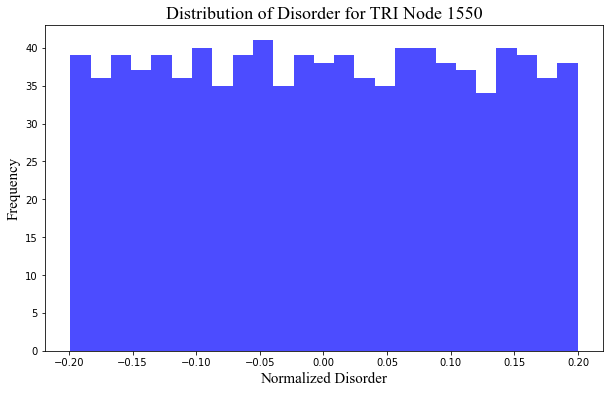

In [7]:
plot_sampling(DAT.UT_dIN_df, DAT.LAT, l, indx=None, num=1, by="Node")

In [8]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    DAT.UT_stats = get_stats(DAT.UT_props_df)
    DAT.UT_nSims = locSims(DAT.UT_props_df)
    print("FINAL UT SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
    print(f"{pd.concat([DAT.UT_stats, DAT.UT_nSims])}\n\n")

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    DAT.FT_stats = get_stats(DAT.FT_props_df)
    DAT.FT_nSims = locSims(DAT.FT_props_df)
    print("FINAL FT SIMULATION COUNT:", len(DAT.FT_OUT_df)-1)
    print(f"{pd.concat([DAT.FT_stats, DAT.FT_nSims])}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        DATc.UT_stats = get_stats(DATc.UT_props_df)
        DATc.UT_nSims = locSims(DATc.UT_props_df)
        print("FINAL UT SIMULATION COUNT:", len(DATc.UT_OUT_df)-1)
        print(f"{pd.concat([DATc.UT_stats, DATc.UT_nSims])}\n\n")

    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        DATc.FT_stats = get_stats(DATc.FT_props_df)
        DATc.FT_nSims = locSims(DATc.FT_props_df)
        print("FINAL FT SIMULATION COUNT:", len(DATc.FT_OUT_df)-1)
        print(f"{pd.concat([DATc.FT_stats, DATc.FT_nSims])}\n\n")

FINAL UT SIMULATION COUNT: 944
       Ductility    Strength    Stiffness         WoF
Mean    0.030596   60.154489  8275.804296    1.481857
Std     0.002442    0.657008    27.317794    0.130836
Max   655.000000  642.000000   776.000000  547.000000
Min    23.000000  863.000000   274.000000  330.000000


FINAL FT SIMULATION COUNT: 986
             K_JIC          K_IC          Force  Displacement
Mean  3.780326e+07  2.908703e+07  142674.539047      0.008133
Std   5.237438e+06  1.926136e+06    9447.875141      0.001453
Max   4.360000e+02  8.860000e+02     886.000000    436.000000
Min   4.290000e+02  3.570000e+02     357.000000    429.000000



=============== COMPARISON DATA ===============

FINAL UT SIMULATION COUNT: 992
       Ductility    Strength    Stiffness         WoF
Mean    0.038470   63.388869  8591.900880    2.031994
Std     0.002552    0.582860     8.702419    0.149084
Max   673.000000  818.000000   450.000000  242.000000
Min    47.000000  612.000000   189.000000  446.000000


F

In [9]:
# FT_OUT_df.index.get_loc(FT_OUT_df[FT_OUT_df.index == 182].index[0])

# Plot Distribution & Identify Max, Min Simulations

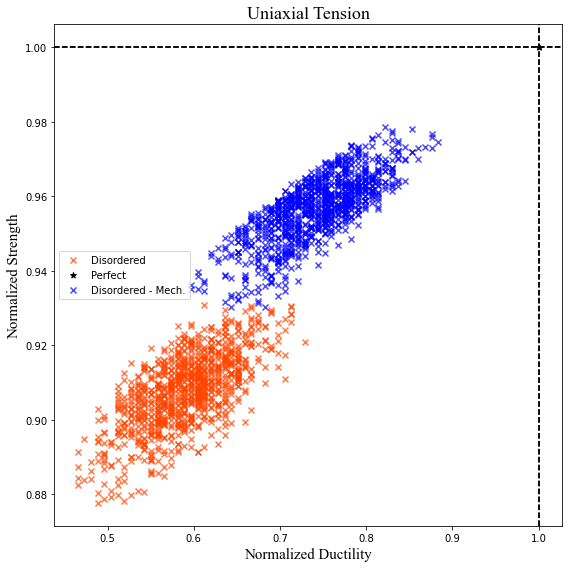

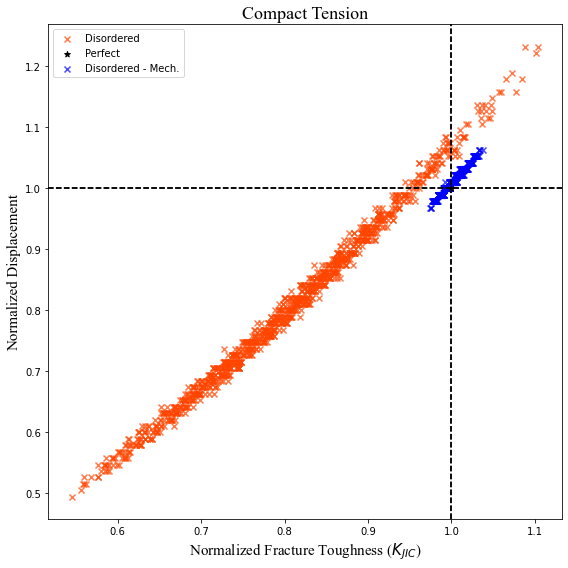

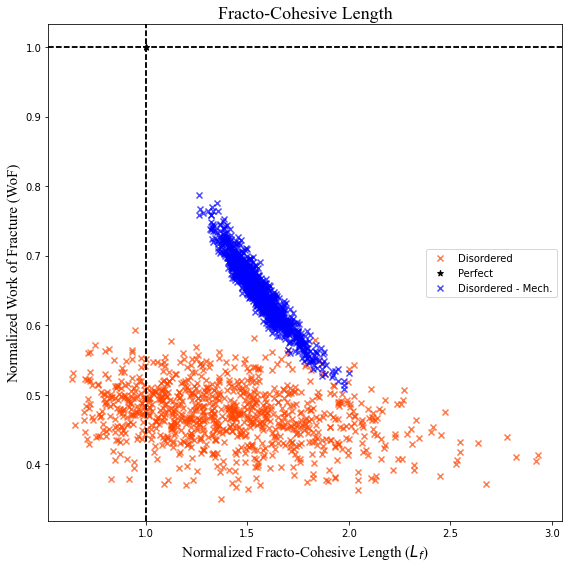

In [10]:
plot_props = True
plot_freq = False
plot_ONLY_freq = False

if plot_props:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.UT_props_df["Ductility"], DAT.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.UT_props_df["Ductility"], DATc.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=(fig, ax))
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.FT_props_df["K_JIC"], DAT.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.FT_props_df["K_JIC"], DATc.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=(fig, ax))
    if MODEL.lower() == "both":
        fig, ax = plot_properties(DAT.common_props_df["FCL"], DAT.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_props_df["FCL"], DATc.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=(fig, ax))

if plot_ONLY_freq:
    if MODEL.lower() == "ductile" or MODEL.lower() == "both":
        plot_frequency(DAT.UT_props_r_df["Ductility"], DAT.UT_props_df["Ductility"], "UT", bins=30)
    if MODEL.lower() == "fracture" or MODEL.lower() == "both":
        plot_frequency(DAT.FT_props_r_df["K_JIC"], DAT.FT_props_df["K_JIC"], "FT", bins=30)
    if MODEL.lower() == "both":
        plot_frequency(DAT.common_props_df["FCL"], DAT.common_props_df["FCL"], "FCL", bins=30)

# Plots UT and FT Curves

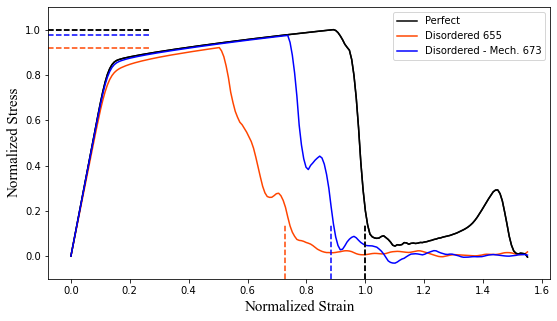

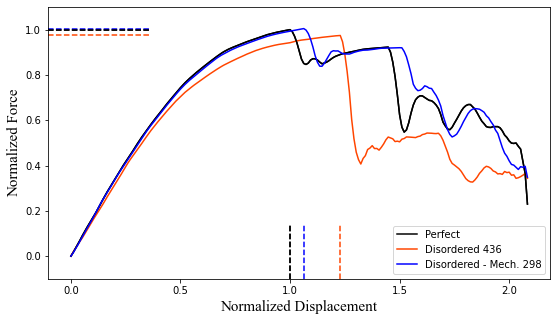

In [11]:
# [UT_nSim_max1, UT_nSim_min1, UT_nSim_max2, UT_nSim_min2, UT_nSim_max3, UT_nSim_min3, UT_nSim_max12, UT_nSim_min12]
# [FT_nSim_max1, FT_nSim_min1, FT_nSim_max2, FT_nSim_min2, FT_nSim_max3, FT_nSim_min3, FT_nSim_max13, FT_nSim_min13]
idx = None
q   = "all"
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, DAT.UT_xOUT, "ut", pi=0, idx=[DAT.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, DATc.UT_xOUT, "ut", pi=0, idx=[DATc.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, DAT.FT_xOUT, "ft", pi=0, idx=[DAT.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, DATc.FT_xOUT, "ft", pi=0, idx=[DATc.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=(fig2, ax1))